In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import os
import random

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed()

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 2e-5
NUM_CLASSES = 4
DATA_DIR = "/kaggle/input/datasets/ninadaithal/imagesoasis/Data"

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
# Test if GPU actually works despite the warning
x = torch.randn(3, 3, 224, 224).to(DEVICE)
print("Tensor on:", x.device)
print("CUDA actually working:", x.is_cuda)

Tensor on: cuda:0
CUDA actually working: True


In [3]:
from torchvision.datasets import ImageFolder

# ViT expects specific normalization (ImageNet stats)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets
full_dataset = ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
print("Classes:", class_names)

# Same 70/15/15 split as notebook 02
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

# WeightedRandomSampler for class imbalance
targets = [full_dataset.targets[i] for i in train_dataset.indices]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Train: 60505 | Val: 12965 | Test: 12967


In [4]:
# Load pretrained ViT-B/16 from timm
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 85,801,732
Trainable parameters: 85,801,732


In [5]:
# Class weights for imbalanced data
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer & scheduler
optimizer = Adam(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Optimizer: Adam | LR: {LR}")
print(f"Scheduler: CosineAnnealingLR | T_max: {EPOCHS}")
print(f"Class weights: {class_weights.round(4)}")

Optimizer: Adam | LR: 2e-05
Scheduler: CosineAnnealingLR | T_max: 10
Class weights: [0.0003 0.0032 0.     0.0001]


In [6]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    # Validation phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    # Record metrics
    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    train_accs.append(100 * train_correct / train_total)
    val_accs.append(100 * val_correct / val_total)

    
    # Step scheduler
    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.2f}% | "
          f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

Epoch [1/10] Train Loss: 0.0300 | Train Acc: 87.85% | Val Loss: 0.0636 | Val Acc: 95.77%
Epoch [2/10] Train Loss: 0.0114 | Train Acc: 96.33% | Val Loss: 0.1851 | Val Acc: 84.03%
Epoch [3/10] Train Loss: 0.0032 | Train Acc: 97.40% | Val Loss: 0.0465 | Val Acc: 96.01%
Epoch [4/10] Train Loss: 0.0016 | Train Acc: 98.95% | Val Loss: 0.0055 | Val Acc: 99.68%
Epoch [5/10] Train Loss: 0.0019 | Train Acc: 98.96% | Val Loss: 0.1493 | Val Acc: 85.96%
Epoch [6/10] Train Loss: 0.0003 | Train Acc: 99.74% | Val Loss: 0.0032 | Val Acc: 99.86%
Epoch [7/10] Train Loss: 0.0000 | Train Acc: 99.99% | Val Loss: 0.0021 | Val Acc: 99.95%
Epoch [8/10] Train Loss: 0.0002 | Train Acc: 99.87% | Val Loss: 0.0009 | Val Acc: 99.95%
Epoch [9/10] Train Loss: 0.0000 | Train Acc: 99.99% | Val Loss: 0.0005 | Val Acc: 99.98%
Epoch [10/10] Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0005 | Val Acc: 99.98%


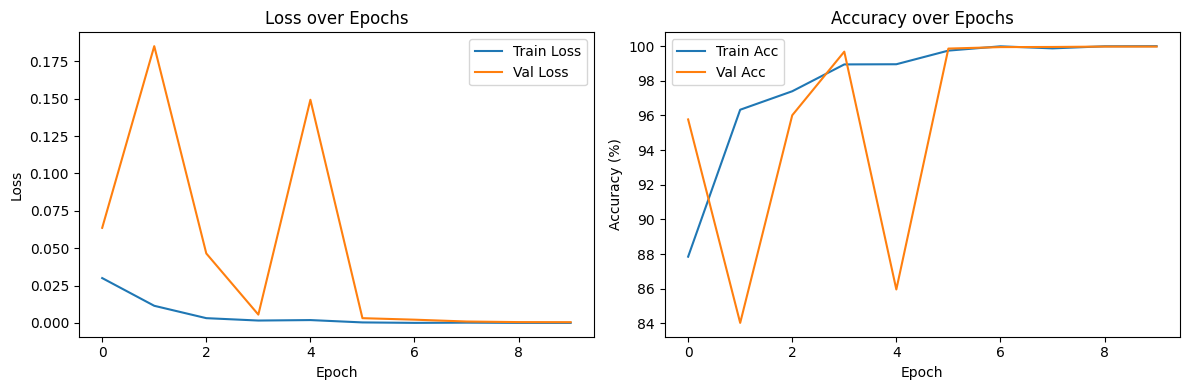

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()

In [8]:
model.eval()
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 99.97%
                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00       742
 Moderate Dementia       1.00      1.00      1.00        82
      Non Demented       1.00      1.00      1.00     10061
Very mild Dementia       1.00      1.00      1.00      2082

          accuracy                           1.00     12967
         macro avg       1.00      1.00      1.00     12967
      weighted avg       1.00      1.00      1.00     12967



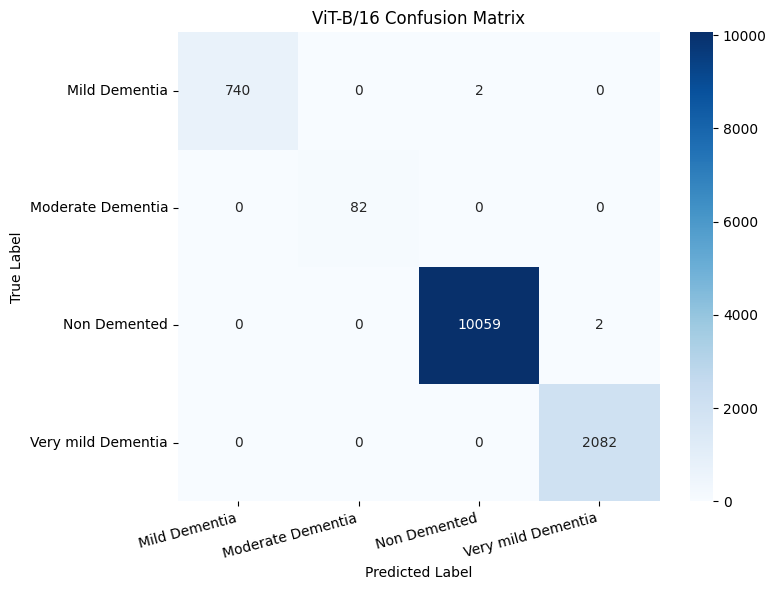

In [9]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('ViT-B/16 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
torch.save(model.state_dict(), 'vit_finetune.pth')
print("Model saved as vit_finetune.pth")

Model saved as vit_finetune.pth
